# Variational Autoencoder (VAE) for EEG Data Augmentation

### 1. EEG Data Processing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path 
import mne

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import tensorflow as tf
from tensorflow.keras import layers, models

2026-04-18 17:06:05.583919: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def find_project_root():
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Project root (with .git) not found")

PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "nm000114"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_features"
RESULTS_DIR = PROJECT_ROOT / "results"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

PROJECT_ROOT: /Users/trinityho/chem_277b/MSSE-277b-final-project-
RAW_DATA_DIR: /Users/trinityho/chem_277b/MSSE-277b-final-project-/data/raw/nm000114
PROCESSED_DIR: /Users/trinityho/chem_277b/MSSE-277b-final-project-/data/processed_features
RESULTS_DIR: /Users/trinityho/chem_277b/MSSE-277b-final-project-/results


In [3]:
def get_eeg_file(subject_id: str, condition: str):
    """ Get the path to the EEG file for a given subject and condition.
    """
    return RAW_DATA_DIR / subject_id / "eeg" / f"{subject_id}_task-{condition}_eeg.edf"

def infer_label_from_subject(subject_id: str) -> int:
    """
    Infer the label (0 for healthy control, 1 for MDD) from the subject ID.
    """
    subject_upper = subject_id.upper()
    if "HS" in subject_upper:
        return 0
    elif "MDD" in subject_upper:
        return 1 
    else: 
        raise ValueError(f"Could not infer label from subject ID: {subject_id}")
    
def parse_condition_from_filename(filepath: Path) -> str:
    """
    Parse the condition (eyesClosed, eyesOpen, P300) from the filename.
    """
    name = filepath.name 
    if "task-eyesClosed" in name:
        return "eyesClosed"
    elif "task-eyesOpen" in name:
        return "eyesOpen"
    elif "task-P300" in name:
        return "P300"
    else:
        raise ValueError(f"Could not parse condition from filename: {name}")
        
edf_files =sorted(RAW_DATA_DIR.glob("sub*/eeg/*.edf"))
        
rows = []
for filepath in edf_files:
    subject_id = filepath.parts[-3] 
    rows.append({
        "patient_id": subject_id,
        "recording_id": filepath.stem,
        "label": infer_label_from_subject(subject_id),
        "condition": parse_condition_from_filename(filepath),
        "filepath": str(filepath),
    })


# Create a DataFrame from the metadata
metadata_df = pd.DataFrame(rows)
metadata_df.head()

,patient_id,recording_id,label,condition,filepath
0,sub-HS1,sub-HS1_task-P300_eeg,0,P300,/Users/trinityho/chem_277b/MSSE-277b-final-pro...
1,sub-HS1,sub-HS1_task-eyesClosed_eeg,0,eyesClosed,/Users/trinityho/chem_277b/MSSE-277b-final-pro...
2,sub-HS1,sub-HS1_task-eyesOpen_eeg,0,eyesOpen,/Users/trinityho/chem_277b/MSSE-277b-final-pro...
3,sub-HS10,sub-HS10_task-P300_eeg,0,P300,/Users/trinityho/chem_277b/MSSE-277b-final-pro...
4,sub-HS10,sub-HS10_task-eyesClosed_eeg,0,eyesClosed,/Users/trinityho/chem_277b/MSSE-277b-final-pro...


In [4]:
print("Shape:", metadata_df.shape)
print("\nUnique patients:", metadata_df["patient_id"].nunique())
print("\nClass counts:")
print(metadata_df["label"].value_counts())
print("\nCondition counts:")
print(metadata_df["condition"].value_counts())
print("\nRecordings per patient:")
print(metadata_df.groupby("patient_id").size().value_counts())

metadata_path = PROCESSED_DIR / "metadata.csv"
metadata_df.to_csv(metadata_path, index=False)
print("\nMetadata saved to:", metadata_path)

Shape: (181, 5)

Unique patients: 64

Class counts:
label
1    95
0    86
Name: count, dtype: int64

Condition counts:
condition
eyesOpen      62
P300          61
eyesClosed    58
Name: count, dtype: int64

Recordings per patient:
3    52
2    10
4     1
1     1
Name: count, dtype: int64

Metadata saved to: /Users/trinityho/chem_277b/MSSE-277b-final-project-/data/processed_features/metadata.csv


In [5]:
COMMON_CHANNELS = [
'EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE',
 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 
 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 
 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1'
]

print("Number of common channels:", len(COMMON_CHANNELS))

Number of common channels: 20


In [6]:
def extract_band_power(raw, COMMON_CHANNELS) -> np.ndarray:
    """
    Extract relative band-power features for each EEG channel in the raw MNE object.
    Returns a feature vector.
    """

    data_raw = raw.copy()
    data_raw.pick(COMMON_CHANNELS)
    
    # get data 
    data = data_raw.get_data()      # shape: (n_channels, n_time points)
    sfreq = data_raw.info['sfreq']  # sampling frequency (e.g. 256 Hz)

    # Define frequency bands 
    bands = {
        "delta": (1, 4),     # deep sleep
        "theta": (4, 8),     # drowsiness
        "alpha": (8, 13),    # relaxed 
        "beta":  (13, 30)    # active thinking 
    }

    all_features = []

    # Loop through each channel (ch) and convert signal to frequency domain using Welch's method to estimate power spectral density (psd)
    for ch in data:        
        psd, freqs = mne.time_frequency.psd_array_welch(
            ch,
            sfreq=sfreq,
            fmin=1,
            fmax=30,
            verbose=False
        )

        total_power = psd.sum()
        
        band_features = [
            (
                psd[(freqs >= fmin) & (freqs <= fmax)].mean()
            / total_power                                      # normalize by total power to get relative power in each band
            if total_power > 0 else 0                          # handle case where total power is zero to avoid division by zero
            )                           
            for (fmin, fmax) in bands.values()
            ]
    
        all_features.append(band_features)

    return np.nan_to_num(np.array(all_features).flatten())

Build Feature Matrix

In [7]:
# Build feature matrix 

records = [
    (
        extract_band_power(
            mne.io.read_raw_edf(row["filepath"], preload=True, verbose=False),
            COMMON_CHANNELS
        ),
        row["label"],
        row["patient_id"]
    )
    for _, row in metadata_df.iterrows()
]

X = np.vstack([r[0] for r in records])
y = np.array([r[1] for r in records])
groups = np.array([r[2] for r in records])

print("X.shape:", X.shape)
print("y.shape:", y.shape)
print("Groups shape:", groups.shape)

X.shape: (181, 80)
y.shape: (181,)
Groups shape: (181,)


# VAE for Each Condition (P300, Eyes Open, Eyes Closed)

In [12]:
# VAE components 
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_encoder(input_dim, latent_dim):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dense(64, activation="relu")(x)
    z_mean = layers.Dense(latent_dim)(x)
    z_log_var = layers.Dense(latent_dim)(x)
    return models.Model(inputs, [z_mean, z_log_var])

def build_decoder(output_dim, latent_dim):
    inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(output_dim)(x)
    return models.Model(inputs, outputs)

def compute_loss(x, x_recon, z_mean, z_log_var):
    x = tf.cast(x, tf.float32)
    x_recon = tf.cast(x_recon, tf.float32)
    
    recon = tf.reduce_mean(tf.reduce_sum(tf.square(x - x_recon), axis=1))
    
    kl = -0.5 * tf.reduce_mean(
        tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
    )
    return recon + kl


In [13]:
# train VAE
all_losses = []

def train_vae(X_data, latent_dim=5, epochs=15):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data).astype("float32")

    input_dim = X_scaled.shape[1]

    encoder = build_encoder(input_dim, latent_dim)
    decoder = build_decoder(input_dim, latent_dim)

    optimizer = tf.keras.optimizers.Adam()

    dataset = tf.data.Dataset.from_tensor_slices(X_scaled.astype("float32")).batch(64)

    epoch_losses = [] # track VAE training loss

    for epoch in range(epochs):
        batch_losses = []

        for batch in dataset:
            with tf.GradientTape() as tape:

                z_mean, z_log_var = encoder(batch)
                z = Sampling()([z_mean, z_log_var])
                x_recon = decoder(z)

                loss = compute_loss(batch, x_recon, z_mean, z_log_var)

            grads = tape.gradient(
                loss,
                encoder.trainable_weights + decoder.trainable_weights
            )

            optimizer.apply_gradients(
                zip(grads, encoder.trainable_weights + decoder.trainable_weights)
            )

            batch_losses.append(loss.numpy())

        # average loss for this epoch
        avg_loss = np.mean(batch_losses)
        epoch_losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

    return encoder, decoder, scaler, epoch_losses

# generate synthetic data
def generate_samples(decoder, scaler, latent_dim, n_samples):
    z = np.random.normal(size=(n_samples, latent_dim)).astype("float32")
    X_fake_scaled = decoder.predict(z, verbose=0)
    return scaler.inverse_transform(X_fake_scaled)


In [14]:
# Augmentation of training sets
conditions = ["P300", "eyesOpen", "eyesClosed"]

def augment_training_data(X_train, y_train, metadata_train, vae_models, latent_dim=5, n_fake=100):

    X_aug = [X_train]
    y_aug = [y_train]

    for cond in conditions:

        mask = metadata_train["condition"].values == cond

        if mask.sum() < 10:
            continue

        decoder = vae_models[cond]["decoder"]
        scaler = vae_models[cond]["scaler"]

        for label in [0, 1]:

            z = np.random.normal(size=(n_fake, latent_dim)).astype("float32")

            X_fake_scaled = decoder.predict(z, verbose=0)
            X_fake = scaler.inverse_transform(X_fake_scaled)

            y_fake = np.full(n_fake, label)

            X_aug.append(X_fake)
            y_aug.append(y_fake)

    return np.vstack(X_aug), np.hstack(y_aug)

# Training Loop for Combined Augmented Data

In [15]:
# Apply GroupKFold
all_vae_losses = []
gkf = GroupKFold(n_splits=5)

acc_real = []
acc_aug = []

f1_real = []
f1_aug = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    print(f"\nFold {fold+1}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    metadata_train = metadata_df.iloc[train_idx]

    # train VAE
    vae_models = {}
    vae_losses = {}

    for cond in conditions:

        mask = metadata_train["condition"].values == cond
        X_cond = X_train[mask]

        if len(X_cond) < 10:
            continue

        _, decoder, scaler, losses = train_vae(
            X_cond,
            latent_dim=5,
            epochs=30
        )

        vae_models[cond] = {
            "decoder": decoder,
            "scaler": scaler
        }
        
        vae_losses[cond] = losses
    
    all_vae_losses.append(vae_losses)

    # --- Baseline Model ---
    clf = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))])
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    acc_real.append(accuracy_score(y_test, y_pred))
    f1_real.append(f1_score(y_test, y_pred))

    # --- Augmentation ---
    X_aug, y_aug = augment_training_data(
        X_train,
        y_train,
        metadata_train,
        vae_models
    )

    clf_aug = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))])
    clf_aug.fit(X_aug, y_aug)

    y_pred_aug = clf_aug.predict(X_test)
    acc_aug.append(accuracy_score(y_test, y_pred_aug))
    f1_aug.append(f1_score(y_test, y_pred_aug))

print("\n--- FINAL RESULTS ---")

print("Baseline Accuracy:", np.mean(acc_real))
print("Baseline F1:", np.mean(f1_real))

print("Augmented Accuracy:", np.mean(acc_aug))
print("Augmented F1:", np.mean(f1_aug))


Fold 1
Epoch 1/30 - Loss: 84.1073
Epoch 2/30 - Loss: 83.1290
Epoch 3/30 - Loss: 82.9539
Epoch 4/30 - Loss: 80.9255
Epoch 5/30 - Loss: 80.7452
Epoch 6/30 - Loss: 80.2379
Epoch 7/30 - Loss: 79.7797
Epoch 8/30 - Loss: 79.6299
Epoch 9/30 - Loss: 79.0271
Epoch 10/30 - Loss: 78.7189
Epoch 11/30 - Loss: 78.2608
Epoch 12/30 - Loss: 78.0330
Epoch 13/30 - Loss: 77.1959
Epoch 14/30 - Loss: 75.9911
Epoch 15/30 - Loss: 75.1098
Epoch 16/30 - Loss: 74.3205
Epoch 17/30 - Loss: 72.4995
Epoch 18/30 - Loss: 71.0309
Epoch 19/30 - Loss: 69.1145
Epoch 20/30 - Loss: 66.9746
Epoch 21/30 - Loss: 64.7268
Epoch 22/30 - Loss: 63.7575
Epoch 23/30 - Loss: 60.8178
Epoch 24/30 - Loss: 58.8828
Epoch 25/30 - Loss: 56.8740
Epoch 26/30 - Loss: 54.1856
Epoch 27/30 - Loss: 52.9943
Epoch 28/30 - Loss: 50.8752
Epoch 29/30 - Loss: 50.1938
Epoch 30/30 - Loss: 46.5487
Epoch 1/30 - Loss: 85.3570
Epoch 2/30 - Loss: 83.9127
Epoch 3/30 - Loss: 82.4464
Epoch 4/30 - Loss: 81.3251
Epoch 5/30 - Loss: 80.8350
Epoch 6/30 - Loss: 80.5800

# VAE Training Loss

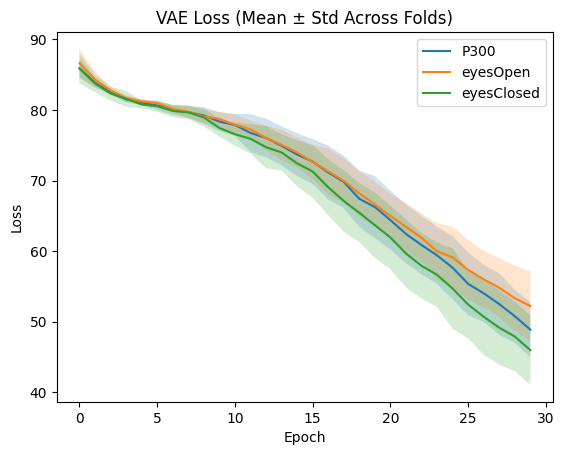

In [16]:
conditions = ["P300", "eyesOpen", "eyesClosed"]

for cond in conditions:
    curves = []

    for fold_losses in all_vae_losses:
        if cond in fold_losses:
            curves.append(fold_losses[cond])

    curves = np.array(curves)  # (folds, epochs)

    mean = curves.mean(axis=0)
    std = curves.std(axis=0)

    x = np.arange(len(mean))

    plt.plot(x, mean, label=cond)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.title("VAE Loss (Mean ± Std Across Folds)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Condtion by Condtion

In [17]:
def augment_training_data_ablation(
    X_train, y_train, metadata_train,
    vae_models,
    target_condition,
    latent_dim=5,
    n_fake=100
):

    X_aug = [X_train]
    y_aug = [y_train]

    mask = metadata_train["condition"].values == target_condition

    if mask.sum() < 10:
        return np.vstack(X_aug), np.hstack(y_aug)

    decoder = vae_models[target_condition]["decoder"]
    scaler = vae_models[target_condition]["scaler"]

    for label in [0, 1]:

        z = np.random.normal(size=(n_fake, latent_dim)).astype("float32")

        X_fake_scaled = decoder.predict(z, verbose=0)
        X_fake = scaler.inverse_transform(X_fake_scaled)

        y_fake = np.full(n_fake, label)

        X_aug.append(X_fake)
        y_aug.append(y_fake)

    return np.vstack(X_aug), np.hstack(y_aug)

In [18]:
conditions = ["P300", "eyesOpen", "eyesClosed"]

# store results across folds
all_ablation_results = []

gkf = GroupKFold(n_splits=5)

# --- Cross Validation Loop --- #
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\n--- Fold {fold+1} ---")

    # Split Data
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    metadata_train = metadata_df.iloc[train_idx]

    # Train VAE
    vae_models = {}

    for cond in conditions:

        mask = metadata_train["condition"].values == cond
        X_cond = X_train[mask]

        if len(X_cond) < 10:
            continue

        encoder, decoder, scaler, _ = train_vae(
            X_cond,
            latent_dim=5,
            epochs=30
        )

        vae_models[cond] = {
            "decoder": decoder,
            "scaler": scaler
        }

    # to store results
    ablation_results = {}

    # conditon by condition
    for cond in conditions:

        # one condition only augmentation
        X_aug, y_aug = augment_training_data_ablation(
            X_train,
            y_train,
            metadata_train,
            vae_models,
            target_condition=cond,
            latent_dim=5,
            n_fake=100
        )

        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("logreg", LogisticRegression(max_iter=1000))
        ])

        clf.fit(X_aug, y_aug)

        # evaluation 
        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        ablation_results[cond] = {
            "acc": acc,
            "f1": f1
        }

        print(f"{cond} | Acc: {acc:.3f} | F1: {f1:.3f}")

    # store fold results
    all_ablation_results.append(ablation_results)

rows = []

for fold_idx, fold_results in enumerate(all_ablation_results):
    for cond, metrics in fold_results.items():
        rows.append({
            "fold": fold_idx,
            "condition": cond,
            "accuracy": metrics["acc"],
            "f1": metrics["f1"]
        })

df = pd.DataFrame(rows)

summary = df.groupby("condition")[["accuracy", "f1"]].mean()

print("\n--- FINAL ABALATION RESULTS ---")
print(summary)


--- Fold 1 ---
Epoch 1/30 - Loss: 85.4302
Epoch 2/30 - Loss: 82.8047
Epoch 3/30 - Loss: 82.5722
Epoch 4/30 - Loss: 81.2931
Epoch 5/30 - Loss: 80.9943
Epoch 6/30 - Loss: 80.8777
Epoch 7/30 - Loss: 80.3871
Epoch 8/30 - Loss: 79.6069
Epoch 9/30 - Loss: 78.8410
Epoch 10/30 - Loss: 78.4975
Epoch 11/30 - Loss: 77.6665
Epoch 12/30 - Loss: 76.9789
Epoch 13/30 - Loss: 75.2364
Epoch 14/30 - Loss: 73.5718
Epoch 15/30 - Loss: 71.7077
Epoch 16/30 - Loss: 70.4695
Epoch 17/30 - Loss: 69.0654
Epoch 18/30 - Loss: 65.9791
Epoch 19/30 - Loss: 64.4081
Epoch 20/30 - Loss: 61.3546
Epoch 21/30 - Loss: 58.7483
Epoch 22/30 - Loss: 56.8143
Epoch 23/30 - Loss: 55.3351
Epoch 24/30 - Loss: 54.0782
Epoch 25/30 - Loss: 51.1850
Epoch 26/30 - Loss: 49.4668
Epoch 27/30 - Loss: 48.9675
Epoch 28/30 - Loss: 46.5809
Epoch 29/30 - Loss: 45.6578
Epoch 30/30 - Loss: 43.2595
Epoch 1/30 - Loss: 88.2774
Epoch 2/30 - Loss: 86.1884
Epoch 3/30 - Loss: 82.8724
Epoch 4/30 - Loss: 82.0566
Epoch 5/30 - Loss: 81.7878
Epoch 6/30 - Loss:

In [19]:
rows = []

# baseline
rows.append({
    "method": "Baseline",
    "accuracy": np.mean(acc_real),
    "f1": np.mean(f1_real)
})

# full augmentation
rows.append({
    "method": "Full Augmentation",
    "accuracy": np.mean(acc_aug),
    "f1": np.mean(f1_aug)
})

# ablations
for cond in conditions:
    rows.append({
        "method": f"{cond}-only",
        "accuracy": summary.loc[cond, "accuracy"],
        "f1": summary.loc[cond, "f1"]
    })
df_all = pd.DataFrame(rows)

df_all["accuracy"] = df_all["accuracy"].round(3)
df_all["f1"] = df_all["f1"].round(3)
print(df_all)

              method  accuracy     f1
0           Baseline     0.763  0.772
1  Full Augmentation     0.707  0.726
2          P300-only     0.768  0.787
3      eyesOpen-only     0.746  0.749
4    eyesClosed-only     0.762  0.770


# Conditional VAE

In [8]:
from sklearn.preprocessing import OneHotEncoder

In [9]:
def build_encoder_c(input_dim, latent_dim, n_conditions, n_labels):
    x_in = layers.Input(shape=(input_dim,))
    c_in = layers.Input(shape=(n_conditions,))
    y_in = layers.Input(shape=(n_labels,))

    h = layers.Concatenate()([x_in, c_in, y_in])

    h = layers.Dense(128, activation="relu")(h)
    h = layers.Dense(64, activation="relu")(h)

    z_mean = layers.Dense(latent_dim)(h)
    z_log_var = layers.Dense(latent_dim)(h)

    return models.Model([x_in, c_in, y_in], [z_mean, z_log_var])

def build_decoder_c(output_dim, latent_dim, n_conditions, n_labels):
    z_in = layers.Input(shape=(latent_dim,))
    c_in = layers.Input(shape=(n_conditions,))
    y_in = layers.Input(shape=(n_labels,))

    h = layers.Concatenate()([z_in, c_in, y_in])

    h = layers.Dense(64, activation="relu")(h)
    h = layers.Dense(128, activation="relu")(h)

    out = layers.Dense(output_dim)(h)

    return models.Model([z_in, c_in, y_in], out)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon
    
def compute_loss(x, x_recon, z_mean, z_log_var):
    recon = tf.reduce_mean(tf.reduce_sum(tf.square(x - x_recon), axis=1))

    kl = -0.5 * tf.reduce_mean(
        tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=1
        )
    )

    return recon + kl

In [10]:
class CVAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        x, c, y = data

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder([x, c, y])
            z = Sampling()([z_mean, z_log_var])

            x_recon = self.decoder([z, c, y])

            loss = compute_loss(x, x_recon, z_mean, z_log_var)

        grads = tape.gradient(
            loss,
            self.encoder.trainable_weights + self.decoder.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.encoder.trainable_weights + self.decoder.trainable_weights)
        )

        return {"loss": loss}

In [11]:
def train_cvae(X, cond, y,
               input_dim,
               latent_dim=5,
               epochs=30,
               n_conditions=3,
               n_labels=2):

    encoder = build_encoder_c(input_dim, latent_dim, n_conditions, n_labels)
    decoder = build_decoder_c(input_dim, latent_dim, n_conditions, n_labels)

    cvae = CVAE(encoder, decoder)
    cvae.compile(optimizer=tf.keras.optimizers.Adam())

    dataset = tf.data.Dataset.from_tensor_slices((X, cond, y)).batch(64)

    losses = []

    for epoch in range(epochs):
        epoch_losses = []

        for batch in dataset:
            logs = cvae.train_step(batch)
            epoch_losses.append(logs["loss"].numpy())

        avg_loss = np.mean(epoch_losses)
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

    return encoder, decoder, losses

In [19]:
# Augmentation

def generate_samples(decoder, n_samples, latent_dim, cond_vec, label_vec):

    z = np.random.normal(size=(n_samples, latent_dim)).astype("float32")

    C = np.repeat(cond_vec[np.newaxis, :], n_samples, axis=0)
    Y = np.repeat(label_vec[np.newaxis, :], n_samples, axis=0)

    return decoder.predict([z, C, Y], verbose=0)


def augment_condition_only(
    X, y, cond_raw,
    decoder,
    cond_encoder,
    label_encoder,
    latent_dim=5,
    n_fake=100
):

    X_aug = [X]
    y_aug = [y]

    for cond_class in cond_encoder.categories_[0]:

        cond_vec = cond_encoder.transform([[cond_class]])[0]

        for label in np.unique(y):

            y_vec = label_encoder.transform([[label]])[0]

            z = np.random.normal(size=(n_fake, latent_dim)).astype("float32")

            C = np.repeat(cond_vec[np.newaxis, :], n_fake, axis=0)
            Y = np.repeat(y_vec[np.newaxis, :], n_fake, axis=0)

            # ✔ FIX: include label again (this matches CVAE training)
            X_fake = decoder.predict([z, C, Y], verbose=0)

            y_fake = np.full(n_fake, label)

            X_aug.append(X_fake)
            y_aug.append(y_fake)

    return np.vstack(X_aug), np.hstack(y_aug)

In [20]:
gkf = GroupKFold(n_splits=5)

acc_real, f1_real = [], []
acc_aug, f1_aug = [], []

all_losses = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\nFOLD {fold+1}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    meta_train = metadata_df.iloc[train_idx]

    # one-hot
    cond_encoder = OneHotEncoder(sparse_output=False)
    label_encoder = OneHotEncoder(sparse_output=False)

    C_train = cond_encoder.fit_transform(
        meta_train["condition"].values.reshape(-1, 1)
    )

    Y_train = label_encoder.fit_transform(
        y_train.reshape(-1, 1)
    )

    # train cvae
    encoder, decoder, losses = train_cvae(
        X_train.astype("float32"),
        C_train.astype("float32"),
        Y_train.astype("float32"),
        input_dim=X_train.shape[1]
    )

    all_losses.append(losses)

    # baseline
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000))
    ])

    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    acc_real.append(accuracy_score(y_test, pred))
    f1_real.append(f1_score(y_test, pred))

    # augmentation
    X_aug, y_aug = augment_condition_only(
        X_train,
        y_train,
        meta_train["condition"].values,
        decoder,
        cond_encoder,
        label_encoder
    )

    clf_aug = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000))
    ])

    clf_aug.fit(X_aug, y_aug)
    pred_aug = clf_aug.predict(X_test)

    acc_aug.append(accuracy_score(y_test, pred_aug))
    f1_aug.append(f1_score(y_test, pred_aug))

    print(f"Baseline F1: {f1_real[-1]:.3f} | Aug F1: {f1_aug[-1]:.3f}")


FOLD 1
Epoch 1/30 - Loss: 3.5519
Epoch 2/30 - Loss: 2.0501
Epoch 3/30 - Loss: 1.3608
Epoch 4/30 - Loss: 1.0857
Epoch 5/30 - Loss: 0.8613
Epoch 6/30 - Loss: 0.7431
Epoch 7/30 - Loss: 0.6915
Epoch 8/30 - Loss: 0.6001
Epoch 9/30 - Loss: 0.5198
Epoch 10/30 - Loss: 0.4360
Epoch 11/30 - Loss: 0.4459
Epoch 12/30 - Loss: 0.4090
Epoch 13/30 - Loss: 0.3841
Epoch 14/30 - Loss: 0.3561
Epoch 15/30 - Loss: 0.3226
Epoch 16/30 - Loss: 0.3153
Epoch 17/30 - Loss: 0.2967
Epoch 18/30 - Loss: 0.2894
Epoch 19/30 - Loss: 0.2697
Epoch 20/30 - Loss: 0.2689
Epoch 21/30 - Loss: 0.2931
Epoch 22/30 - Loss: 0.2468
Epoch 23/30 - Loss: 0.2427
Epoch 24/30 - Loss: 0.2327
Epoch 25/30 - Loss: 0.2255
Epoch 26/30 - Loss: 0.2089
Epoch 27/30 - Loss: 0.2199
Epoch 28/30 - Loss: 0.2148
Epoch 29/30 - Loss: 0.2011
Epoch 30/30 - Loss: 0.2055
Baseline F1: 0.667 | Aug F1: 0.688

FOLD 2
Epoch 1/30 - Loss: 2.5264
Epoch 2/30 - Loss: 1.5254
Epoch 3/30 - Loss: 1.1214
Epoch 4/30 - Loss: 0.8939
Epoch 5/30 - Loss: 0.7328
Epoch 6/30 - Loss:

In [21]:
print("\n--- FINAL RESULTS ---")

print("Baseline Accuracy:", np.mean(acc_real))
print("Baseline F1:", np.mean(f1_real))

print("Augmented Accuracy:", np.mean(acc_aug))
print("Augmented F1:", np.mean(f1_aug))


--- FINAL RESULTS ---
Baseline Accuracy: 0.7626683826683827
Baseline F1: 0.7718487445316713
Augmented Accuracy: 0.740913770913771
Augmented F1: 0.758452380952381
